In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Assuming files are stored in "saved-fees-updated" directory
data_dir = '../coin-selection-c-master/simulation/results'
files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

# Predefined colors for each strategy
strategy_colors = {
#    'MAX_BILLS': 'blue',
#    'CLOSEST_TO_EXPIRE_MIN_BILLS': 'orange',
#    'CLOSEST_TO_EXPIRE_MAX_BILLS': 'cyan',
#    'MAX_BILLS_TIME_TO_EXPIRE_WEIGHTED': 'blue',
    'RANDOM': 'magenta',
#    'MIN_BILLS': 'blue',
#    'EVEN_FROM_MIN_TO_MAX': 'red',
#    'EVEN_FROM_MAX_TO_MIN': 'pink',
    'WALLET_CORE': 'cyan',
    'GREEDY_MIN_TO_MAX_FIX': 'red',
    'GREEDY_MAX_TO_MIN_FIX': 'orange',
    'CALL_EXTERNAL': 'black'
}

# Initialize an empty list to hold all data
all_data = []

# Process each file
for file_name in files:
    file_path = os.path.join(data_dir, file_name)
    with open(file_path, 'r') as file:
        # Read user type and strategy from the first line
        try:
            user_type, strategy = file.readline().strip().split(', ')
        except ValueError:
            print(f"error reading {file_name}")
            continue
        
        # Parse the rest of the data
        for line in file:
            try:
                id, time, amount, operation, fee, coin_count, *counts = line.strip().split(', ')  # Updated here to include 'amount'
            except ValueError:
                print(f"error reading {file_name}")
                continue
            counts = list(counts)
            counts = counts[::2]
            all_data.append({
                "UserType": user_type,
                "Strategy": strategy,
                "Id": id,
                "Time": int(time),
                "Amount": int(amount),  
                "Operation": operation,  
                "Fee": int(fee),
                "FileName": file_name,
                "CoinCount": int(coin_count),
                "CoinCounts": [int(c) for c in counts]
            })

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(all_data)

df.explode("CoinCounts")

df['Days'] = df['Time']/3600/24

df.set_index("Days", inplace=True)

user_types = df["UserType"].unique()
strategies = df["Strategy"].unique()

n_user_types = df["UserType"].nunique()
n_strats = df["Strategy"].nunique()

cols = min(n_user_types, 2)
rows = np.ceil(n_user_types / cols).astype(int)

df["SignAmount"] = 0
df["SignAmount"] = df['Amount'].where(df["Operation"] == "WITHDRAW_OP", -df["Amount"]) - df["Fee"]

file_groups = df.groupby('FileName')
df["Balance"] = file_groups['SignAmount'].cumsum()
# Calculate cumulative fees for each file within each strategy
df['CumulativeFee'] = df.groupby(['FileName', 'UserType', 'Strategy'])['Fee'].cumsum()
fees_by_op = df.groupby(["UserType", "Strategy", "Operation"])["Fee"].sum()

#print(file_groups["CoinCount"].shift(1, fill_value=0) - file_groups["CoinCount"])
df["UsedDiskSpace"] = df["CoinCount"]
df["UsedBandwidth"] = 0
df["UsedBandwidth"] = df.groupby(['FileName', 'UserType', 'Strategy'])["CoinCount"].diff().abs().fillna(0).cumsum()

# ???
df["FeeSumWallet"] = df["CoinCount"] + df["CumulativeFee"]
#print(df.loc[(df["Strategy"] == 'GREEDY_MAX_TO_MIN_FIX') & (df["UserType"] == 'BALANCED_ARTIST')][["Time","CumulativeFee", "Amount", "Fee", "Balance"]])
#print(df.loc[(df["Strategy"] == 'GREEDY_MIN_TO_MAX_FIX') & (df["UserType"] == 'BALANCED_ARTIST')][["Time", "CumulativeFee", "Amount", "Fee", "Balance"]])
print(df["CoinCounts"])



Days
0.0       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
0.0       [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ...
0.0       [0, 1, 1, 2, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2, 1, ...
1.0       [0, 1, 1, 2, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2, 1, ...
1.0       [0, 0, 1, 2, 0, 0, 1, 1, 2, 2, 1, 1, 0, 1, 2, ...
                                ...                        
1078.0    [0, 2, 1, 2, 2, 0, 4, 5, 7, 2, 2, 2, 1, 1, 0, ...
1078.0    [0, 2, 1, 2, 2, 0, 4, 5, 7, 2, 2, 2, 1, 1, 0, ...
1078.0    [0, 1, 2, 1, 0, 1, 3, 1, 7, 3, 0, 2, 1, 0, 0, ...
1078.0    [0, 1, 2, 1, 0, 1, 3, 1, 7, 3, 0, 2, 1, 0, 0, ...
1078.0    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, ...
Name: CoinCounts, Length: 186620, dtype: object


In [15]:
# Plotting setup
num_users = df['UserType'].nunique()
ncols = min(3, num_users)
nrows = np.ceil(num_users / ncols).astype(int)
plot_multiple = ncols * nrows > 1

def plot_grid(key):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)
    
    axes = axes.ravel()
    
    for idx, (user_type, ax) in enumerate(zip(sorted(user_types), axes)):
        # Prepare boxplot data; collect lists from each cell in row corresponding to user type
        user_data = df[(df["UserType"] == user_type)]
        for strategy in strategies:
            #ax.bar(boxplot_data, tick_labels=pivot_df_new.columns, showfliers=False)  # Optionally add `showfliers=False` to hide outliers
            current_data = df[(df["UserType"] == user_type) & (df["Strategy"] == strategy)]
            current_data.plot(y=key, xlabel="Simulation Time (days)", ylabel="Satoshis", label=strategy,
                              ylim=(user_data[key].min(), user_data[key].max()), ax=ax)
            ax.set_title(f"User Type: {user_type}", fontsize=26)
            ax.set_ylabel(key, fontsize=22)
            ax.tick_params(axis='x', rotation=45, labelsize=13)
    
    plt.tight_layout()
    plt.savefig(f"results/{key}", bbox_inches='tight')
    plt.show()
    return fig

    

# Cumulative Fee

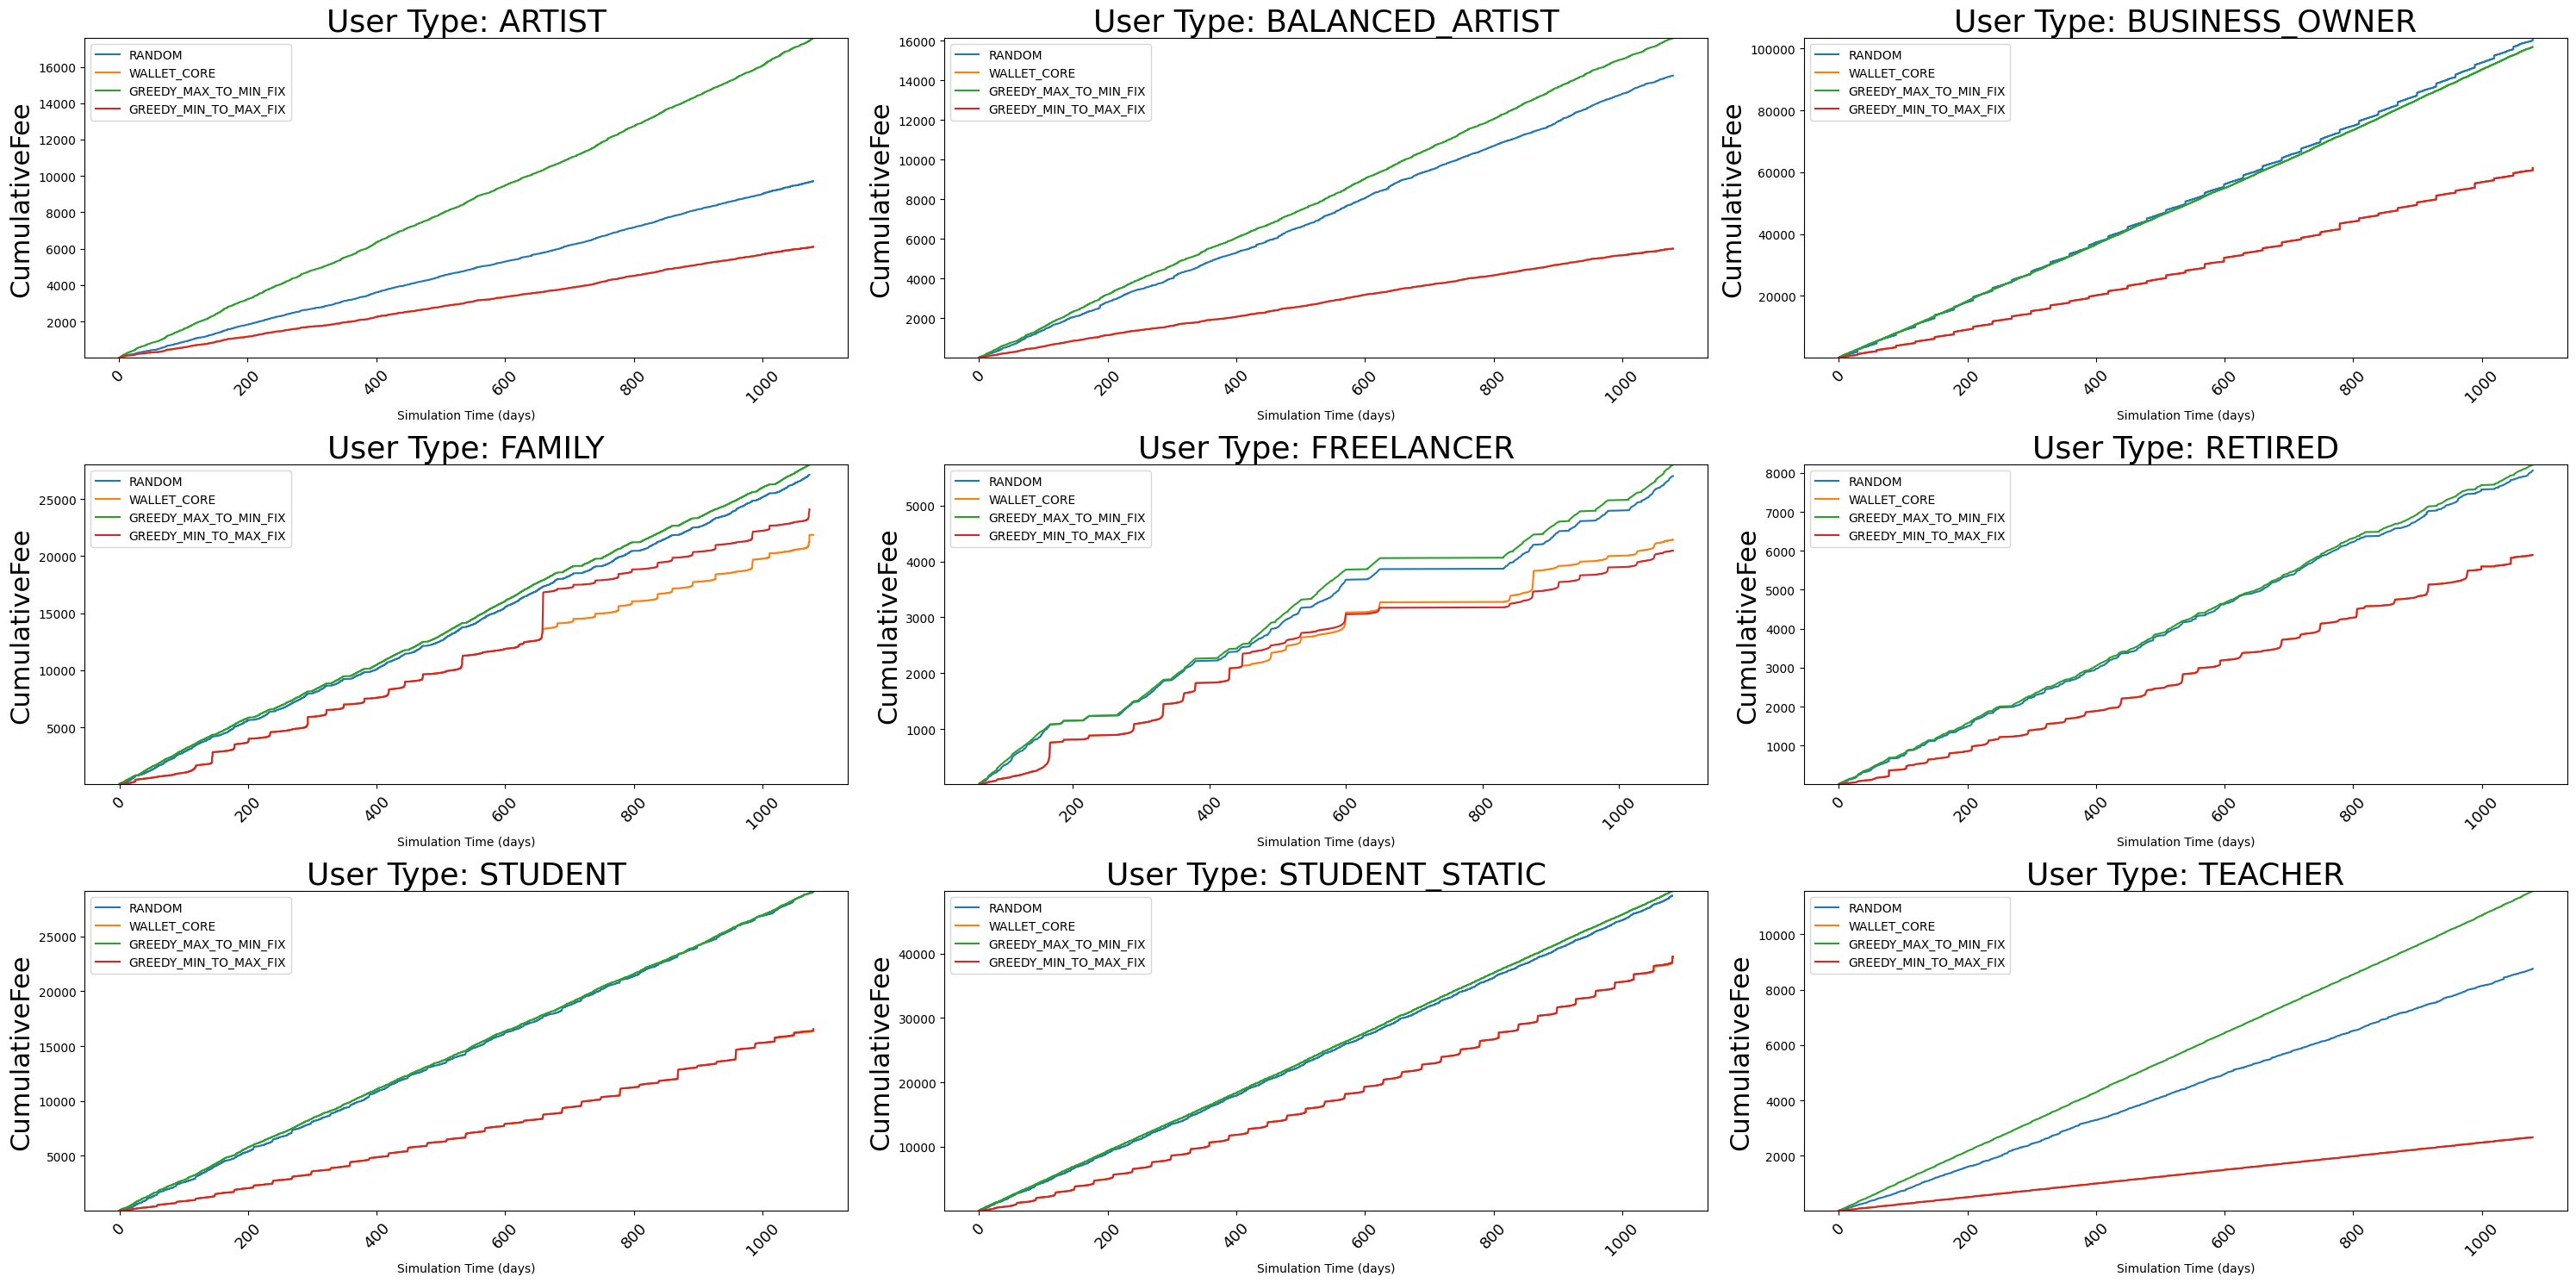

In [16]:
# Create a pivot table for the final cumulative fee for each strategy and user type
final_cumulative_fees = df.drop_duplicates(['FileName', 'UserType', 'Strategy'], keep='last')
# Pivot table adjustment for easier access in the new plot setup
pivot_df_new = final_cumulative_fees.pivot_table(index='UserType', columns='Strategy', values='CumulativeFee', aggfunc=list)

fig = plot_grid("CumulativeFee")
fig.savefig("results/fee_cum_unit", bbox_inches='tight', dpi=300)

# Composition

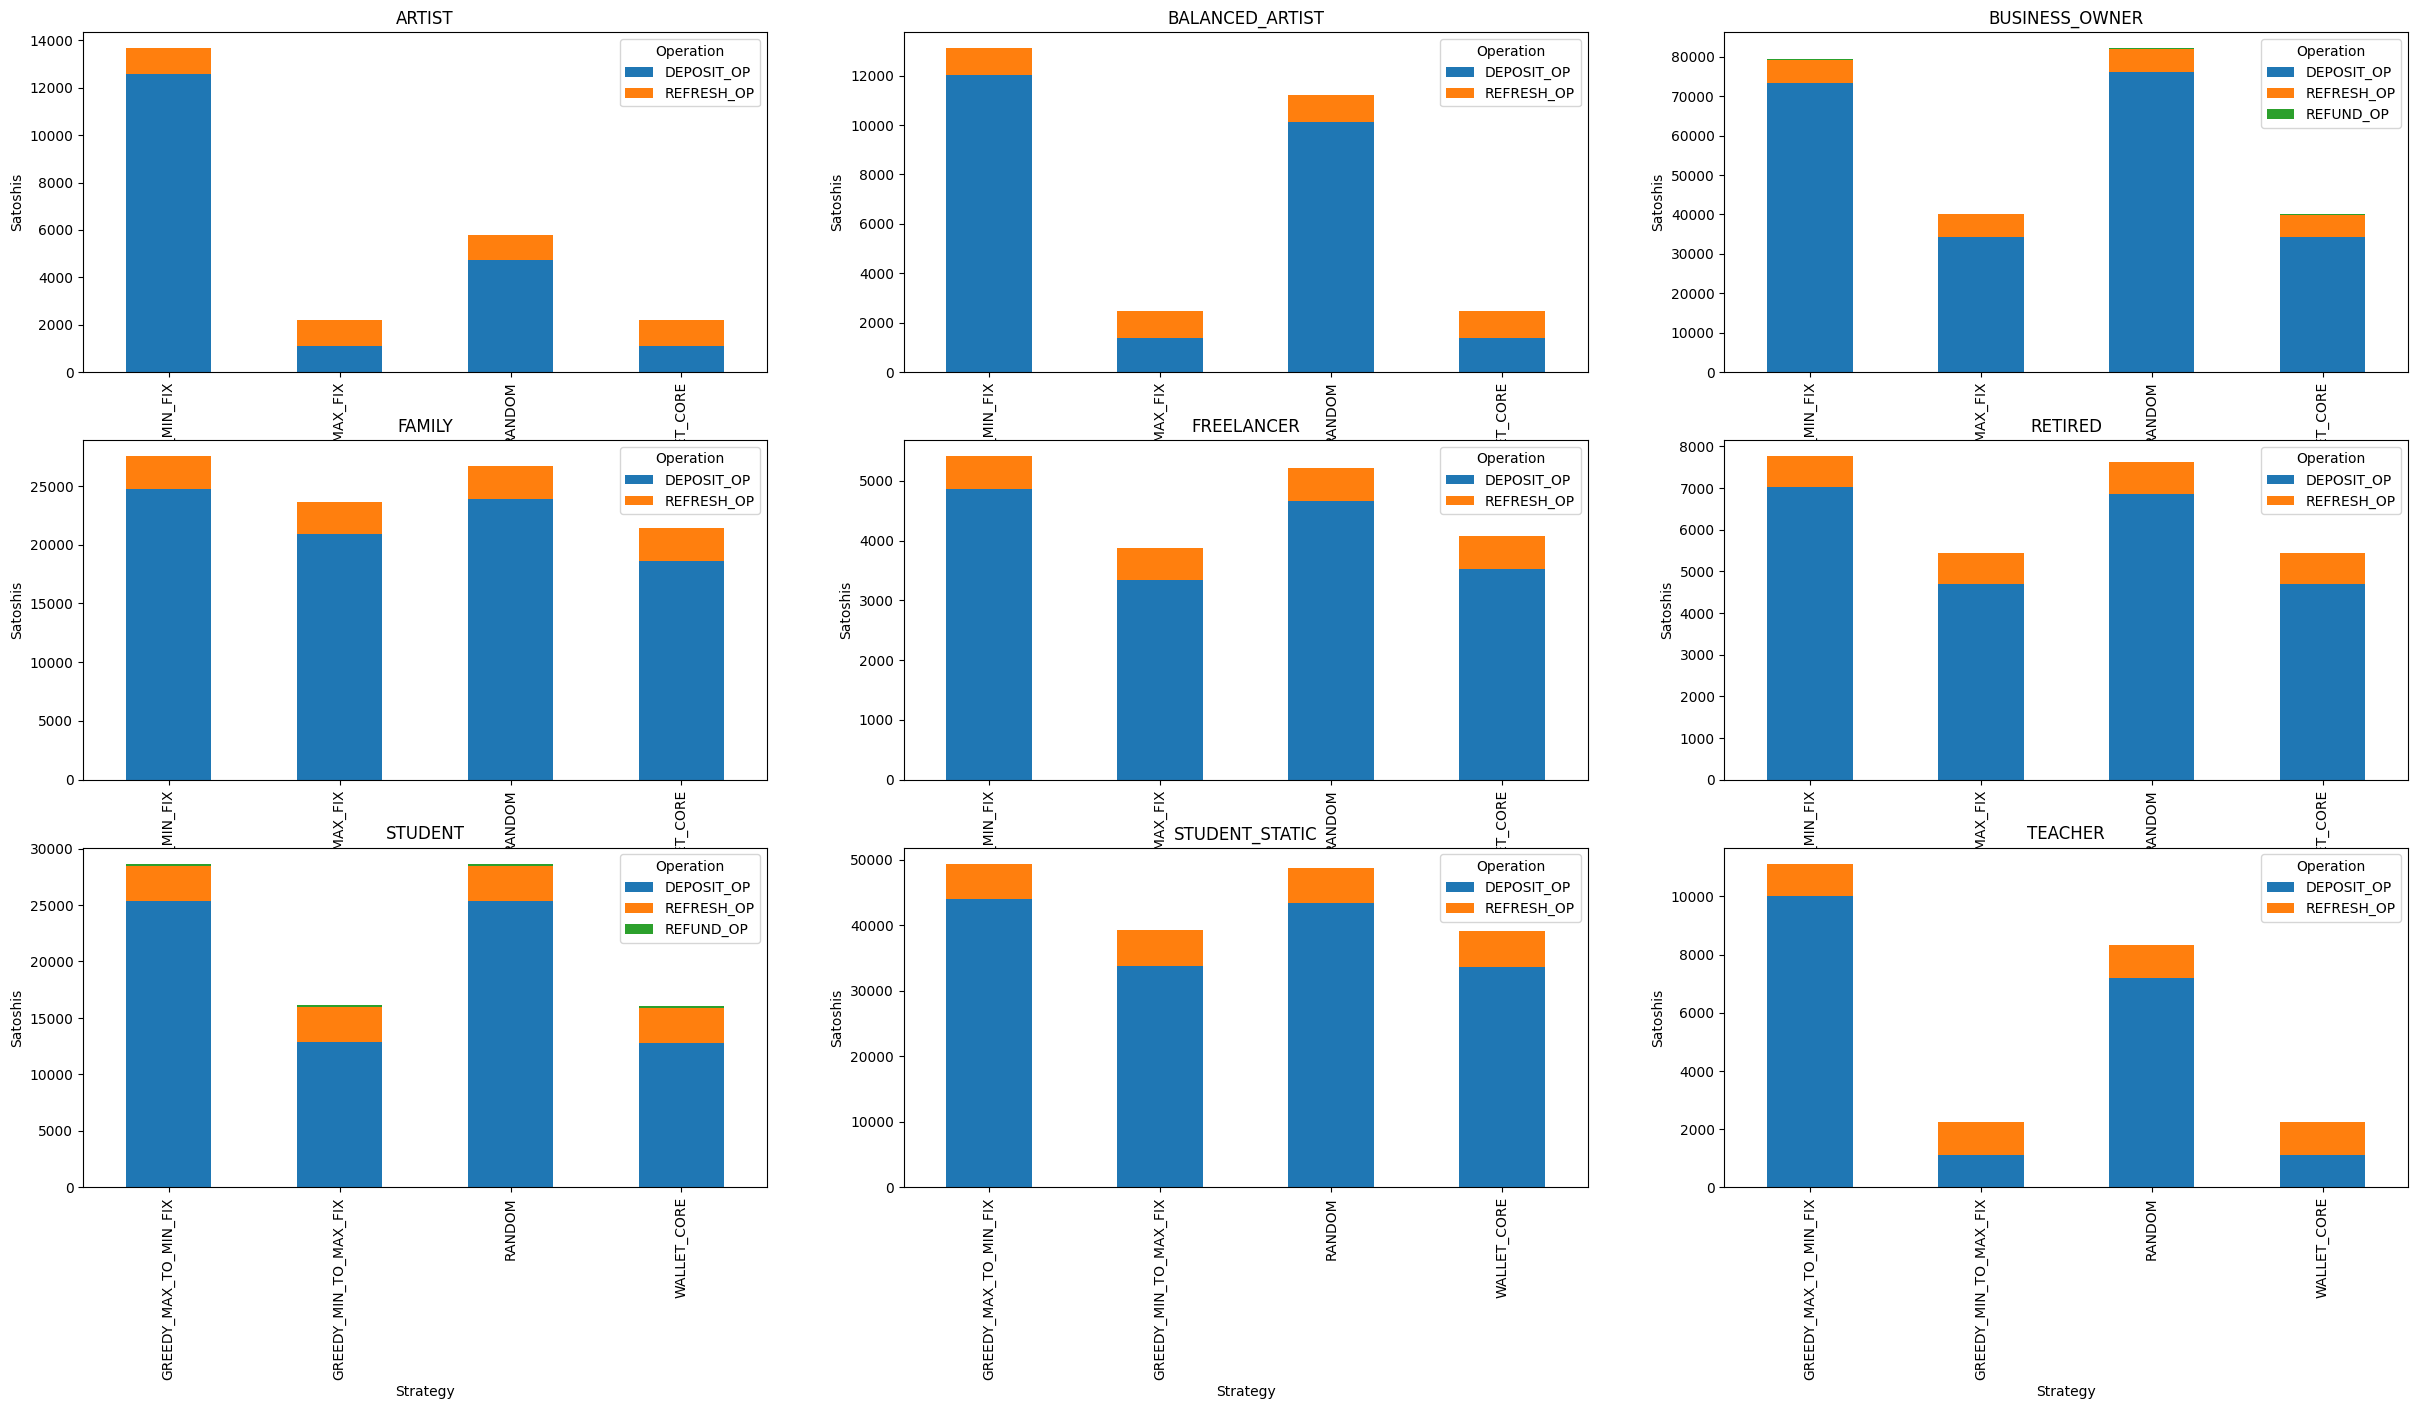

In [17]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)
axes = axes.flatten()
fees_by_op = df.groupby(["UserType", "Strategy", "Operation"])["Fee"].sum().unstack(fill_value=0)
ops = df["Operation"].unique()

# sums = df.groupby(['Strategy', 'Operation', 'UserType'])['Fee'].sum()
# print(sums.max())
# minmax = sums.min(), sums.max()

for idx, (user_type, ax) in enumerate(zip(sorted(user_types), axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type

    current_data = df[(df["UserType"] == user_type) & (df["Operation"] != "WITHDRAW_OP")]
    plot_data = current_data.sort_values(["Strategy", "Operation"]).groupby(["Strategy", "Operation"])["Fee"].sum()

    fig = plot_data.unstack().plot(kind="bar", title=user_type, stacked=True, ylabel="Satoshis", ax=ax).get_figure()

fig.savefig("results/fee_comp_unit", bbox_inches='tight', dpi=300)

# Resources

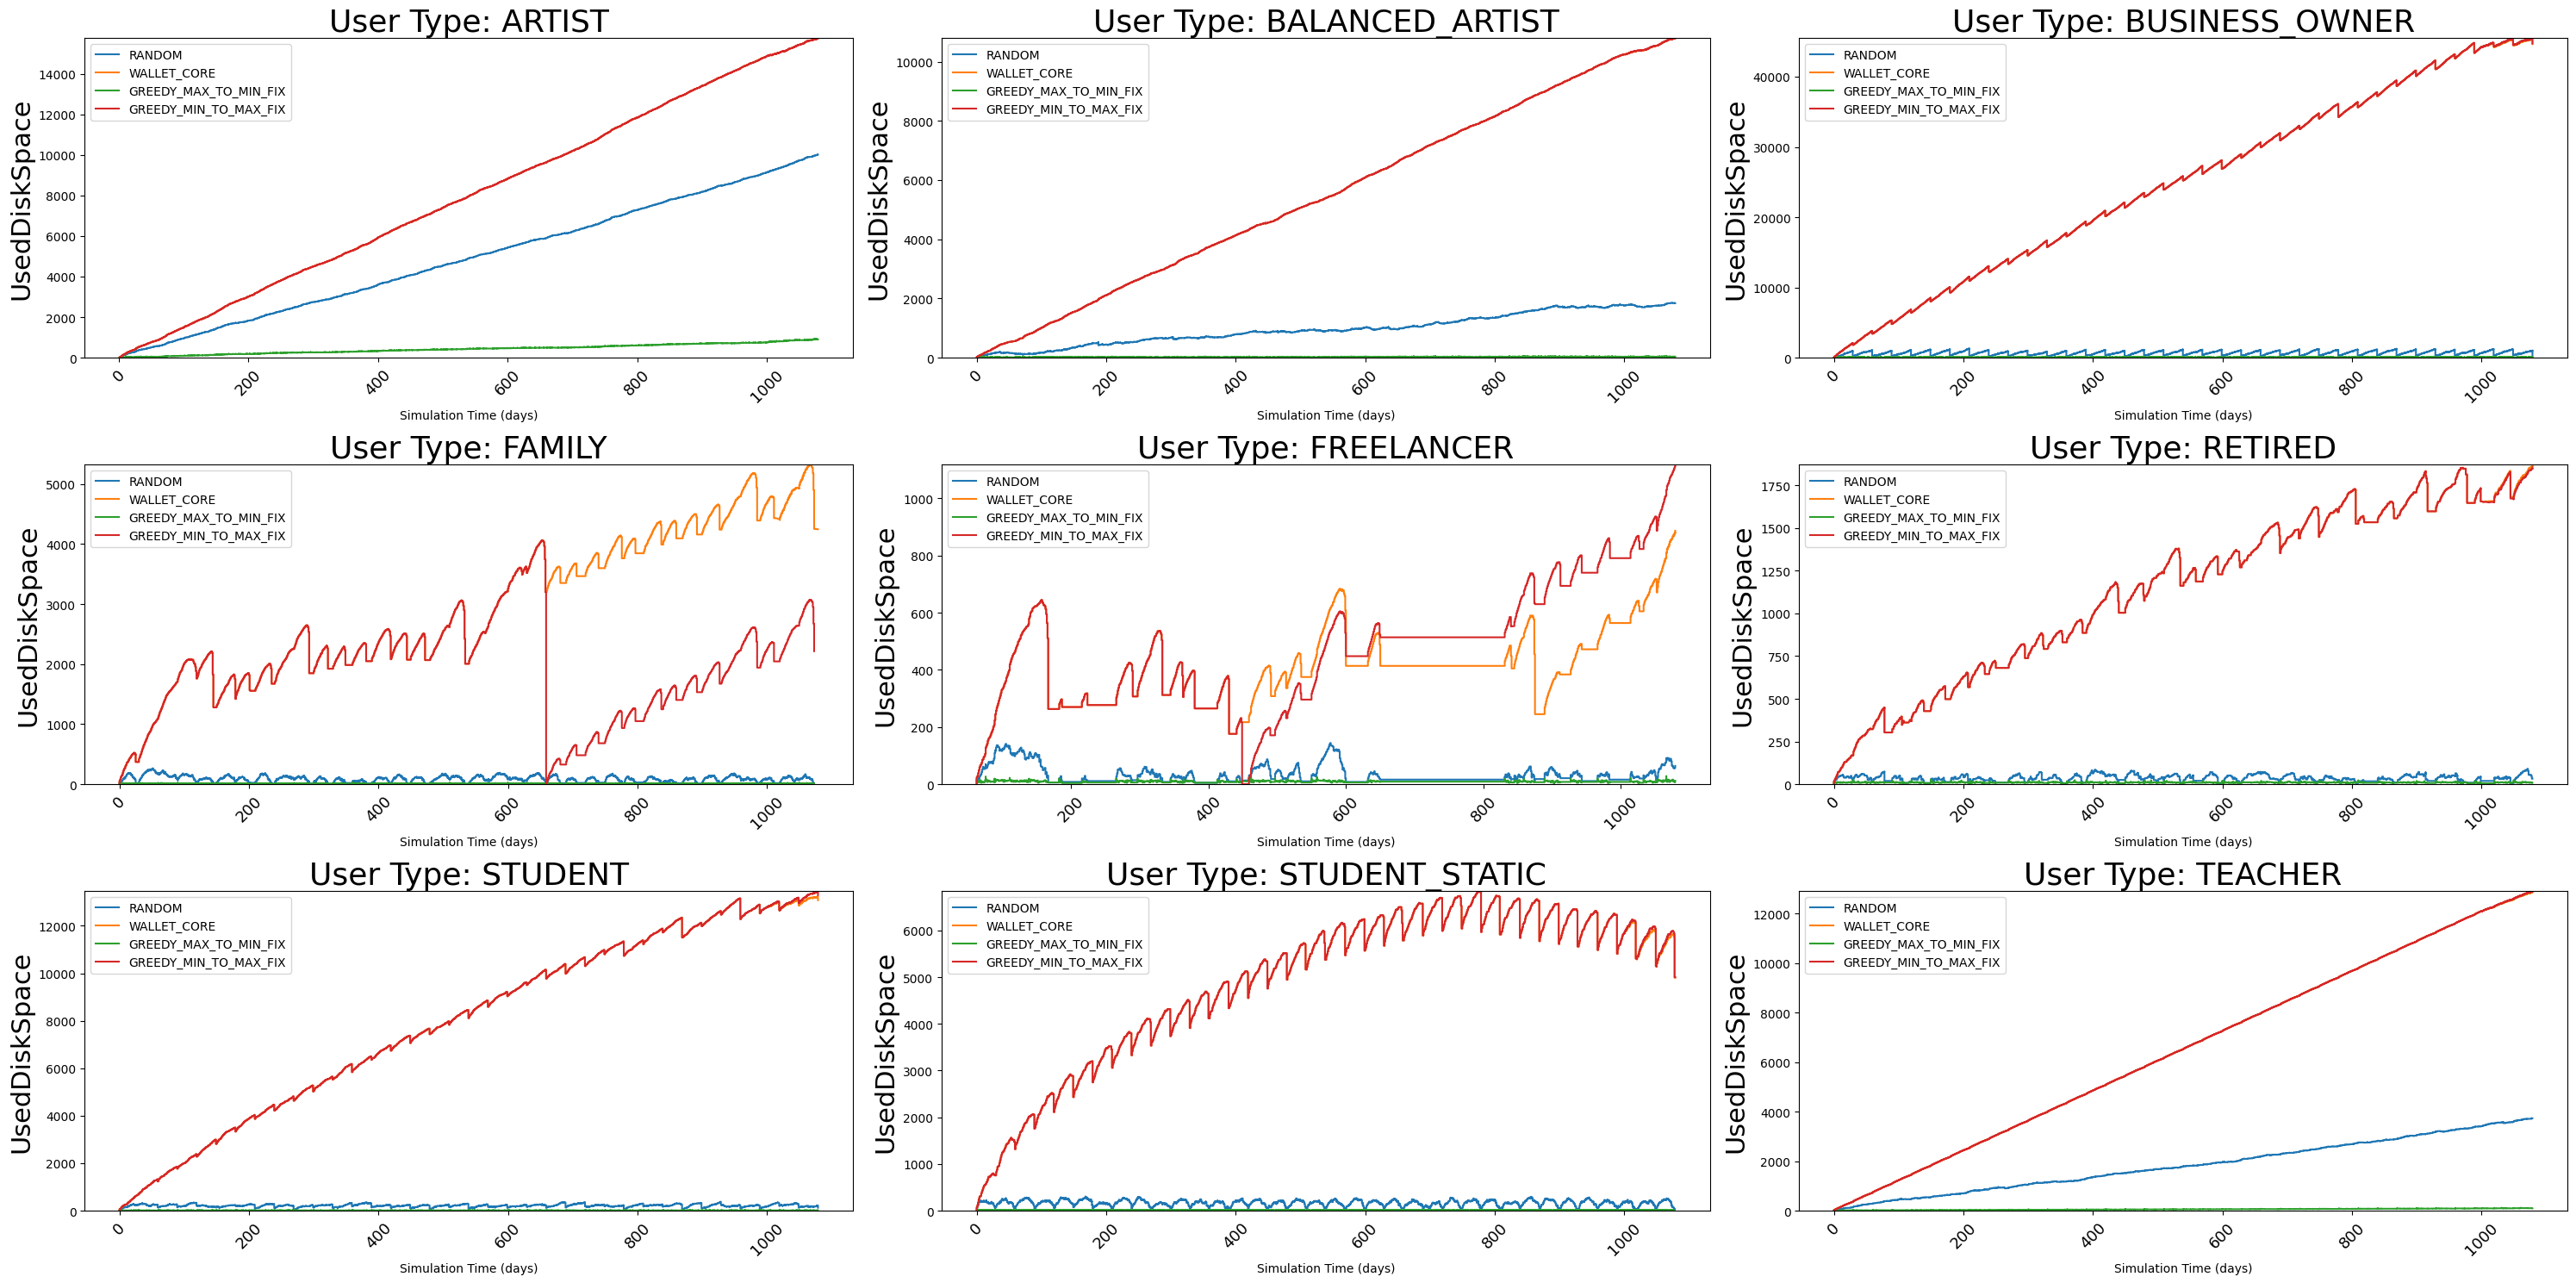

In [18]:
fig = plot_grid("UsedDiskSpace")

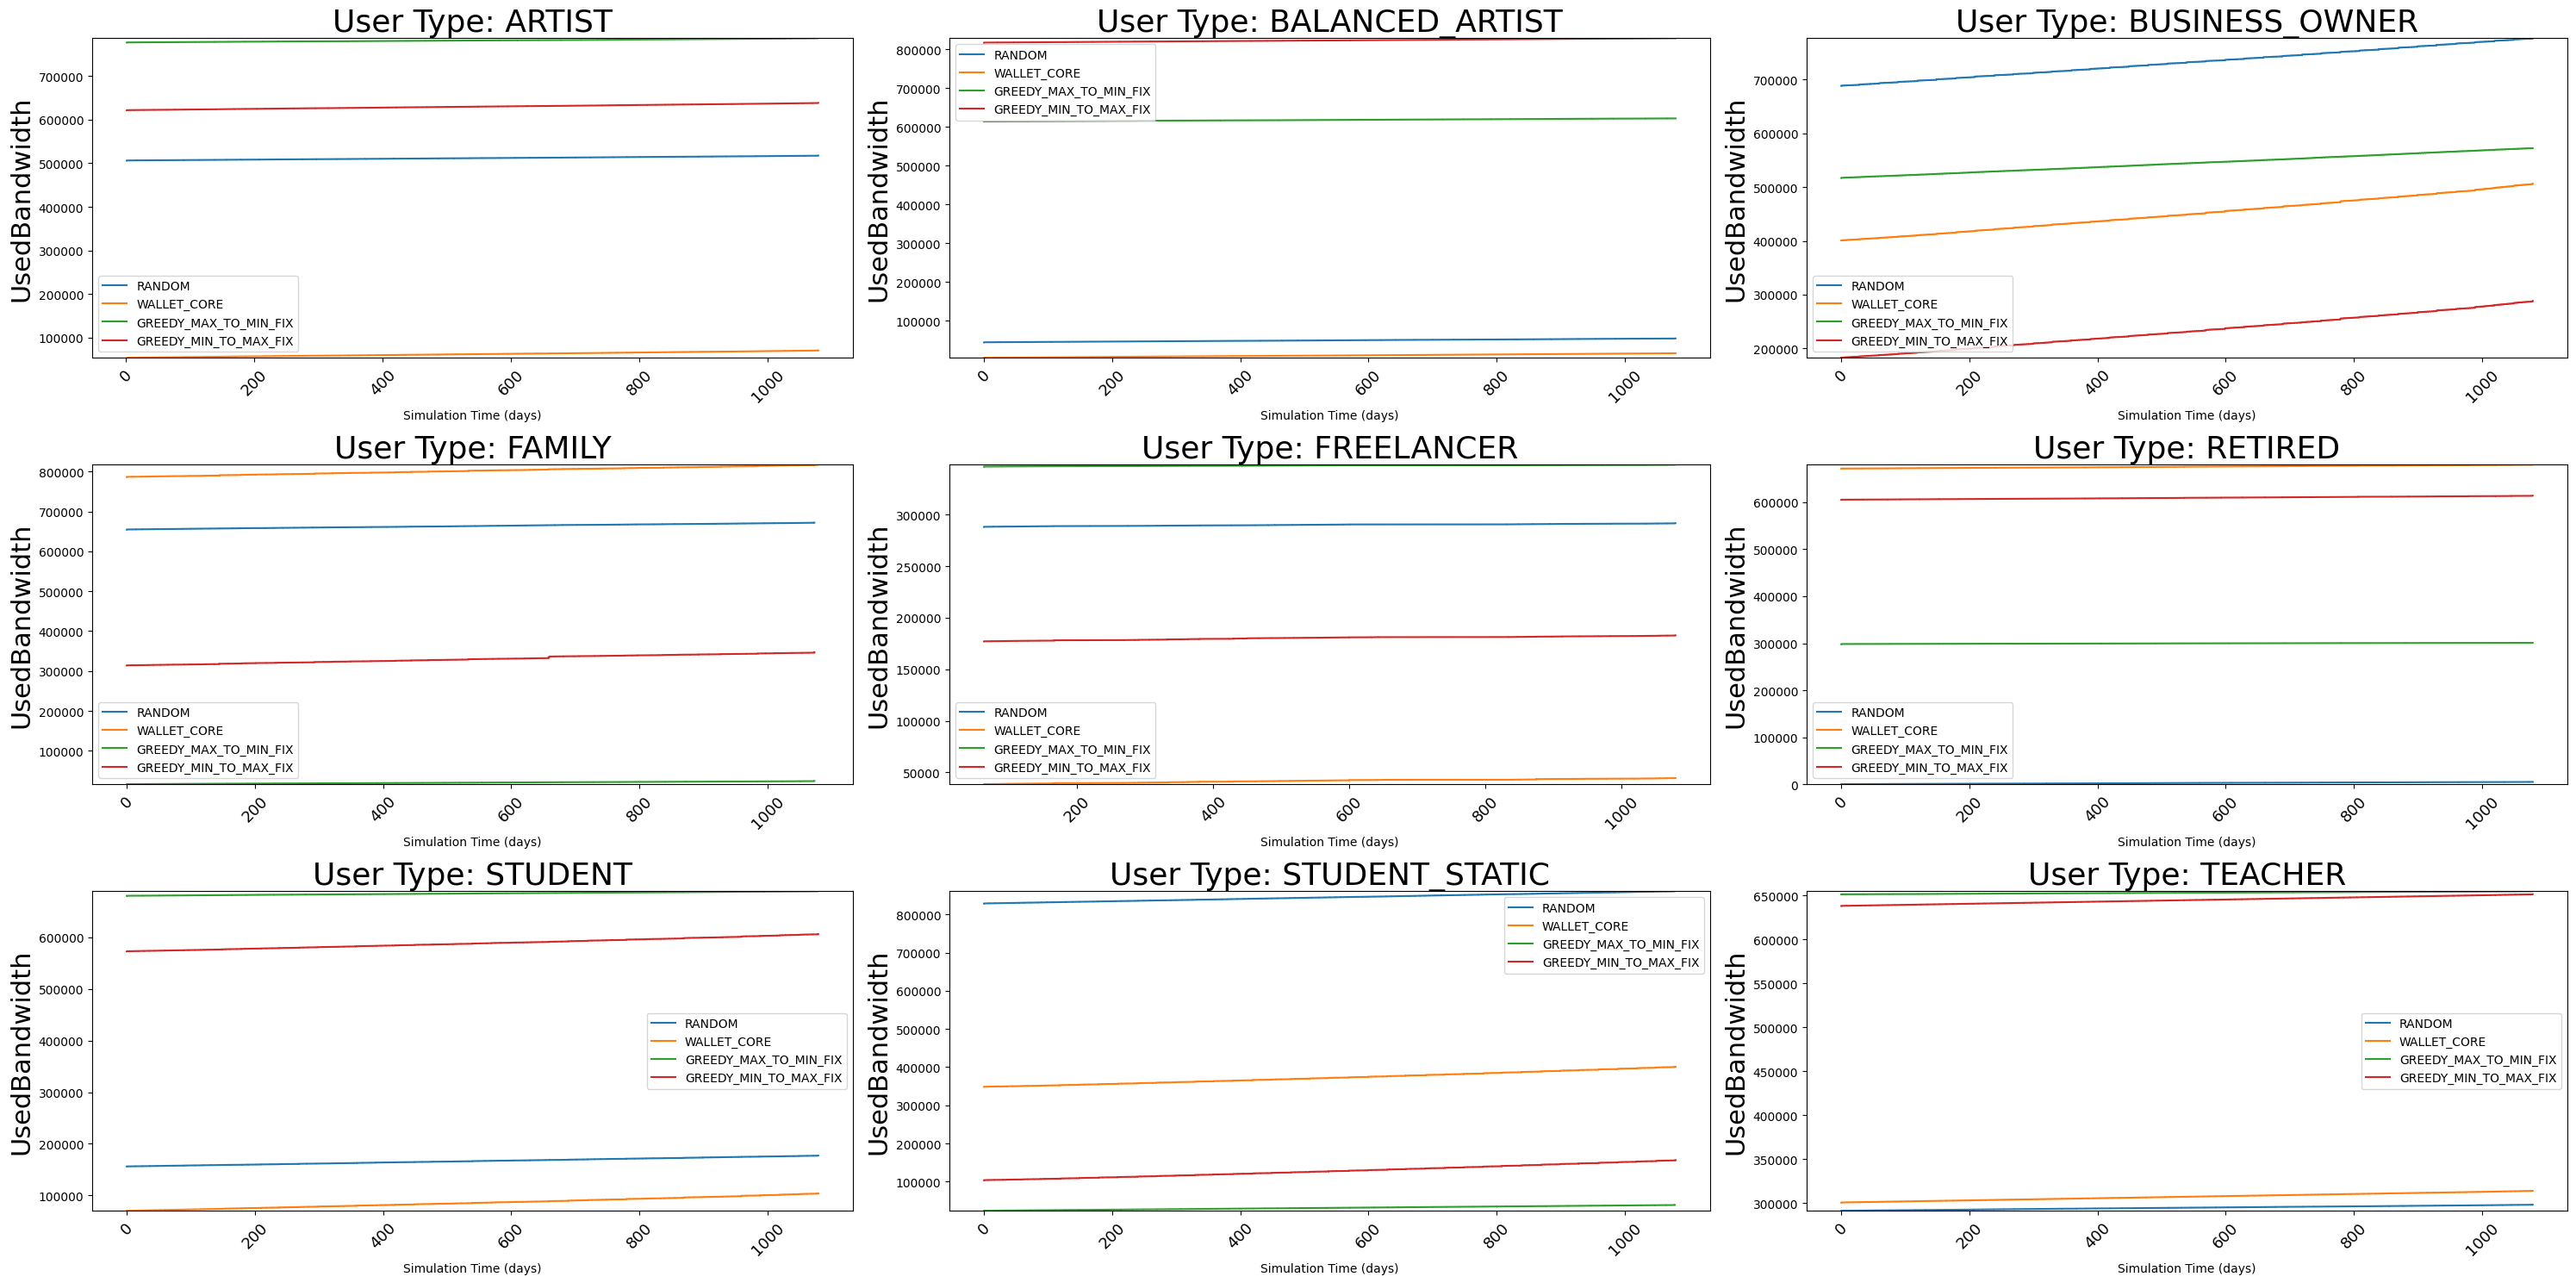

In [19]:
fig = plot_grid("UsedBandwidth")

In [20]:
from src import util

dfs = util.load_all_dfs()

coins_user_0_strategy_GREEDY_MAX_TO_MIN_FIX.json: 0it [00:00, ?it/s]
coins_user_0_strategy_GREEDY_MIN_TO_MAX_FIX.json: 0it [00:00, ?it/s]
coins_user_0_strategy_RANDOM.json: 0it [00:00, ?it/s]
coins_user_0_strategy_WALLET_CORE.json: 0it [00:00, ?it/s]
coins_user_1_strategy_GREEDY_MAX_TO_MIN_FIX.json: 0it [00:00, ?it/s]
coins_user_1_strategy_GREEDY_MIN_TO_MAX_FIX.json: 0it [00:00, ?it/s]
coins_user_1_strategy_RANDOM.json: 0it [00:00, ?it/s]
coins_user_1_strategy_WALLET_CORE.json: 0it [00:00, ?it/s]
coins_user_2_strategy_GREEDY_MAX_TO_MIN_FIX.json: 0it [00:00, ?it/s]
coins_user_2_strategy_GREEDY_MIN_TO_MAX_FIX.json: 0it [00:00, ?it/s]
coins_user_2_strategy_RANDOM.json: 0it [00:00, ?it/s]
coins_user_2_strategy_WALLET_CORE.json: 0it [00:00, ?it/s]
coins_user_3_strategy_GREEDY_MAX_TO_MIN_FIX.json: 0it [00:00, ?it/s]
coins_user_3_strategy_GREEDY_MIN_TO_MAX_FIX.json: 0it [00:00, ?it/s]
coins_user_3_strategy_RANDOM.json: 0it [00:00, ?it/s]
coins_user_3_strategy_WALLET_CORE.json: 0it [00:00, ?it

KeyError: 'FileName'

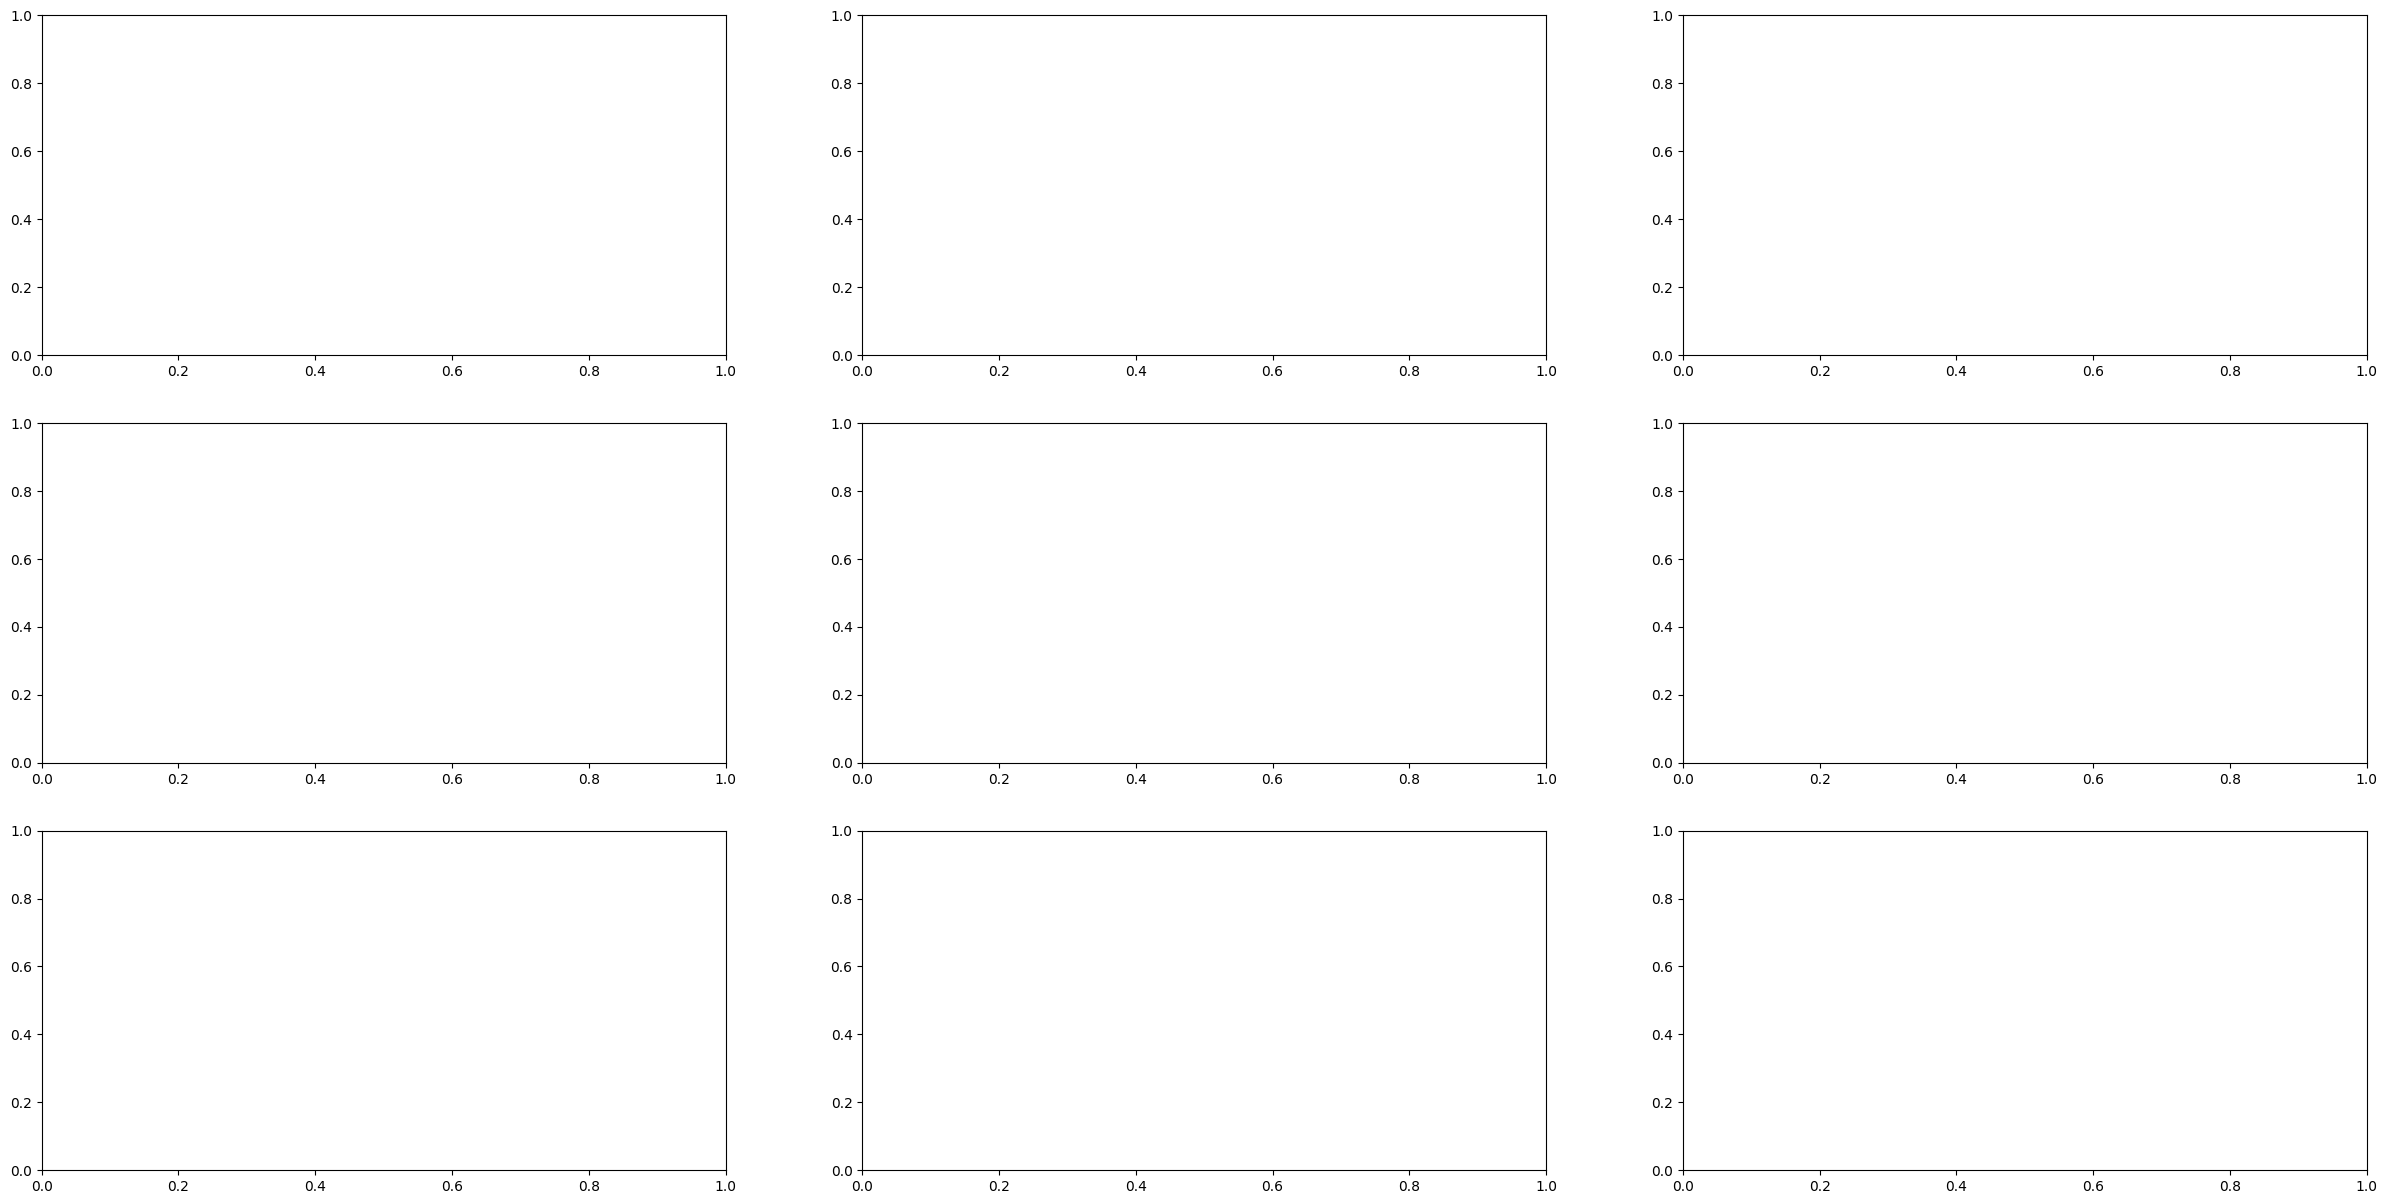

In [21]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 15), squeeze=False)

axes = axes.ravel()

for (file_name, user_df), ax in zip(dfs.groupby('FileName'), axes):
    name = file_name.split(".")[0]
    name = name.removeprefix("coins_user_")
    ax = user_df.plot.area(x="Time", title=name, ax=ax)
    fig = ax.get_figure()
    fig.savefig(f"pictures/area-{name}", dpi=300)

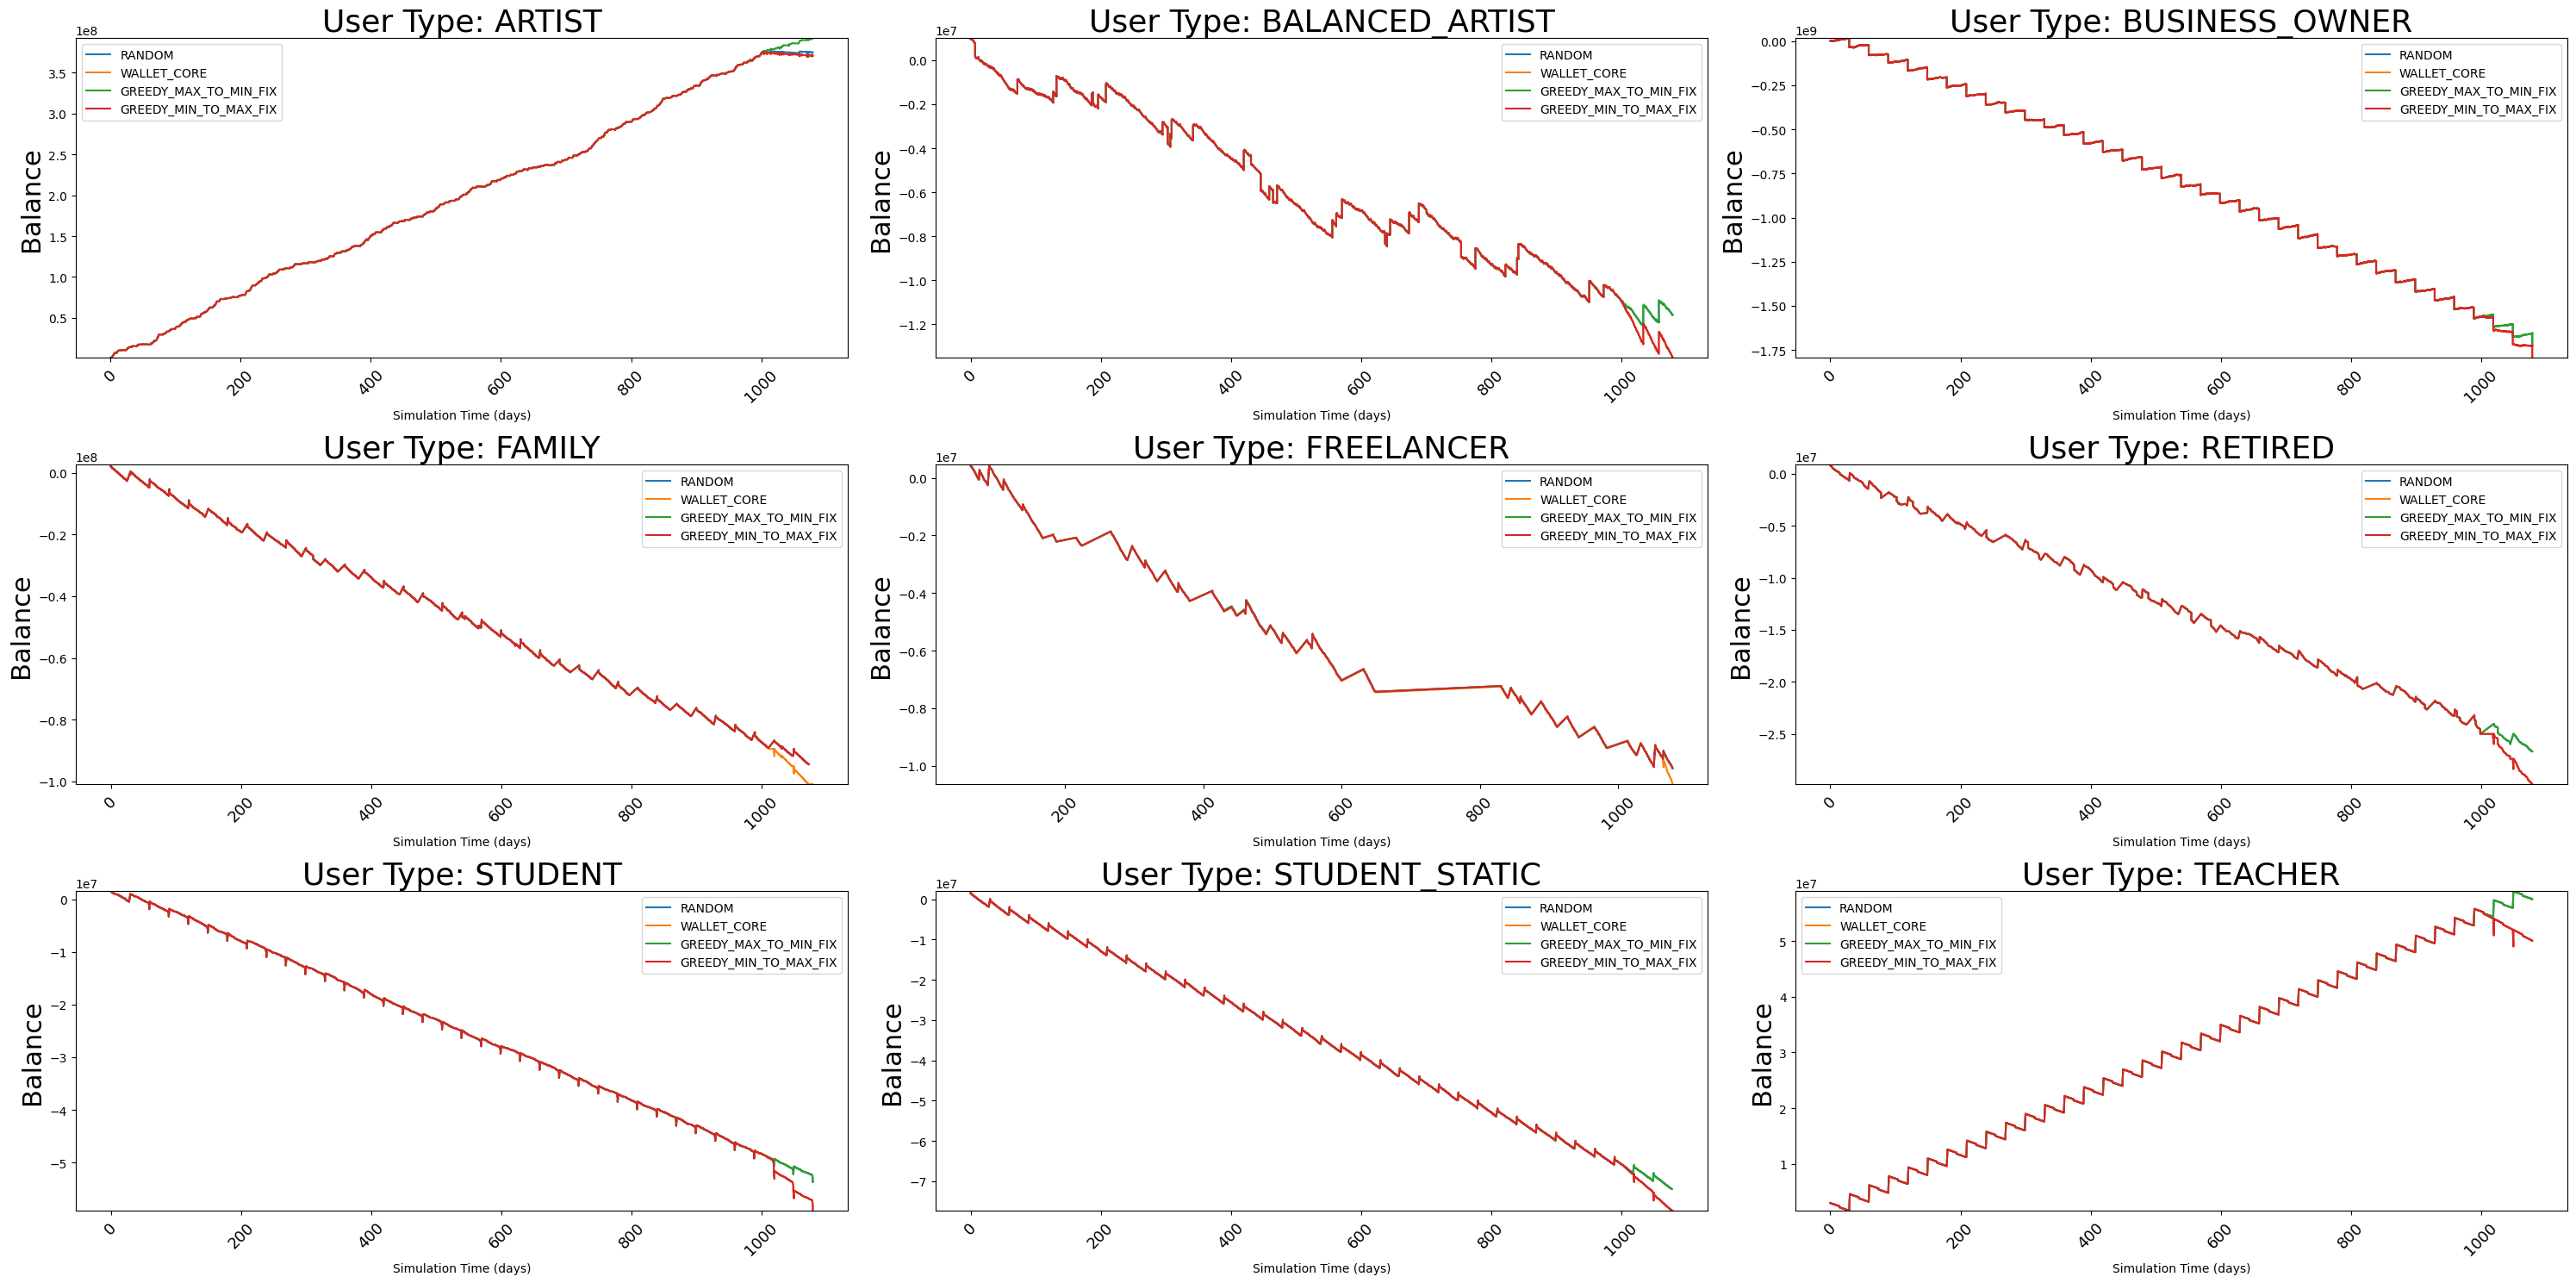

In [23]:
fig = plot_grid("Balance")

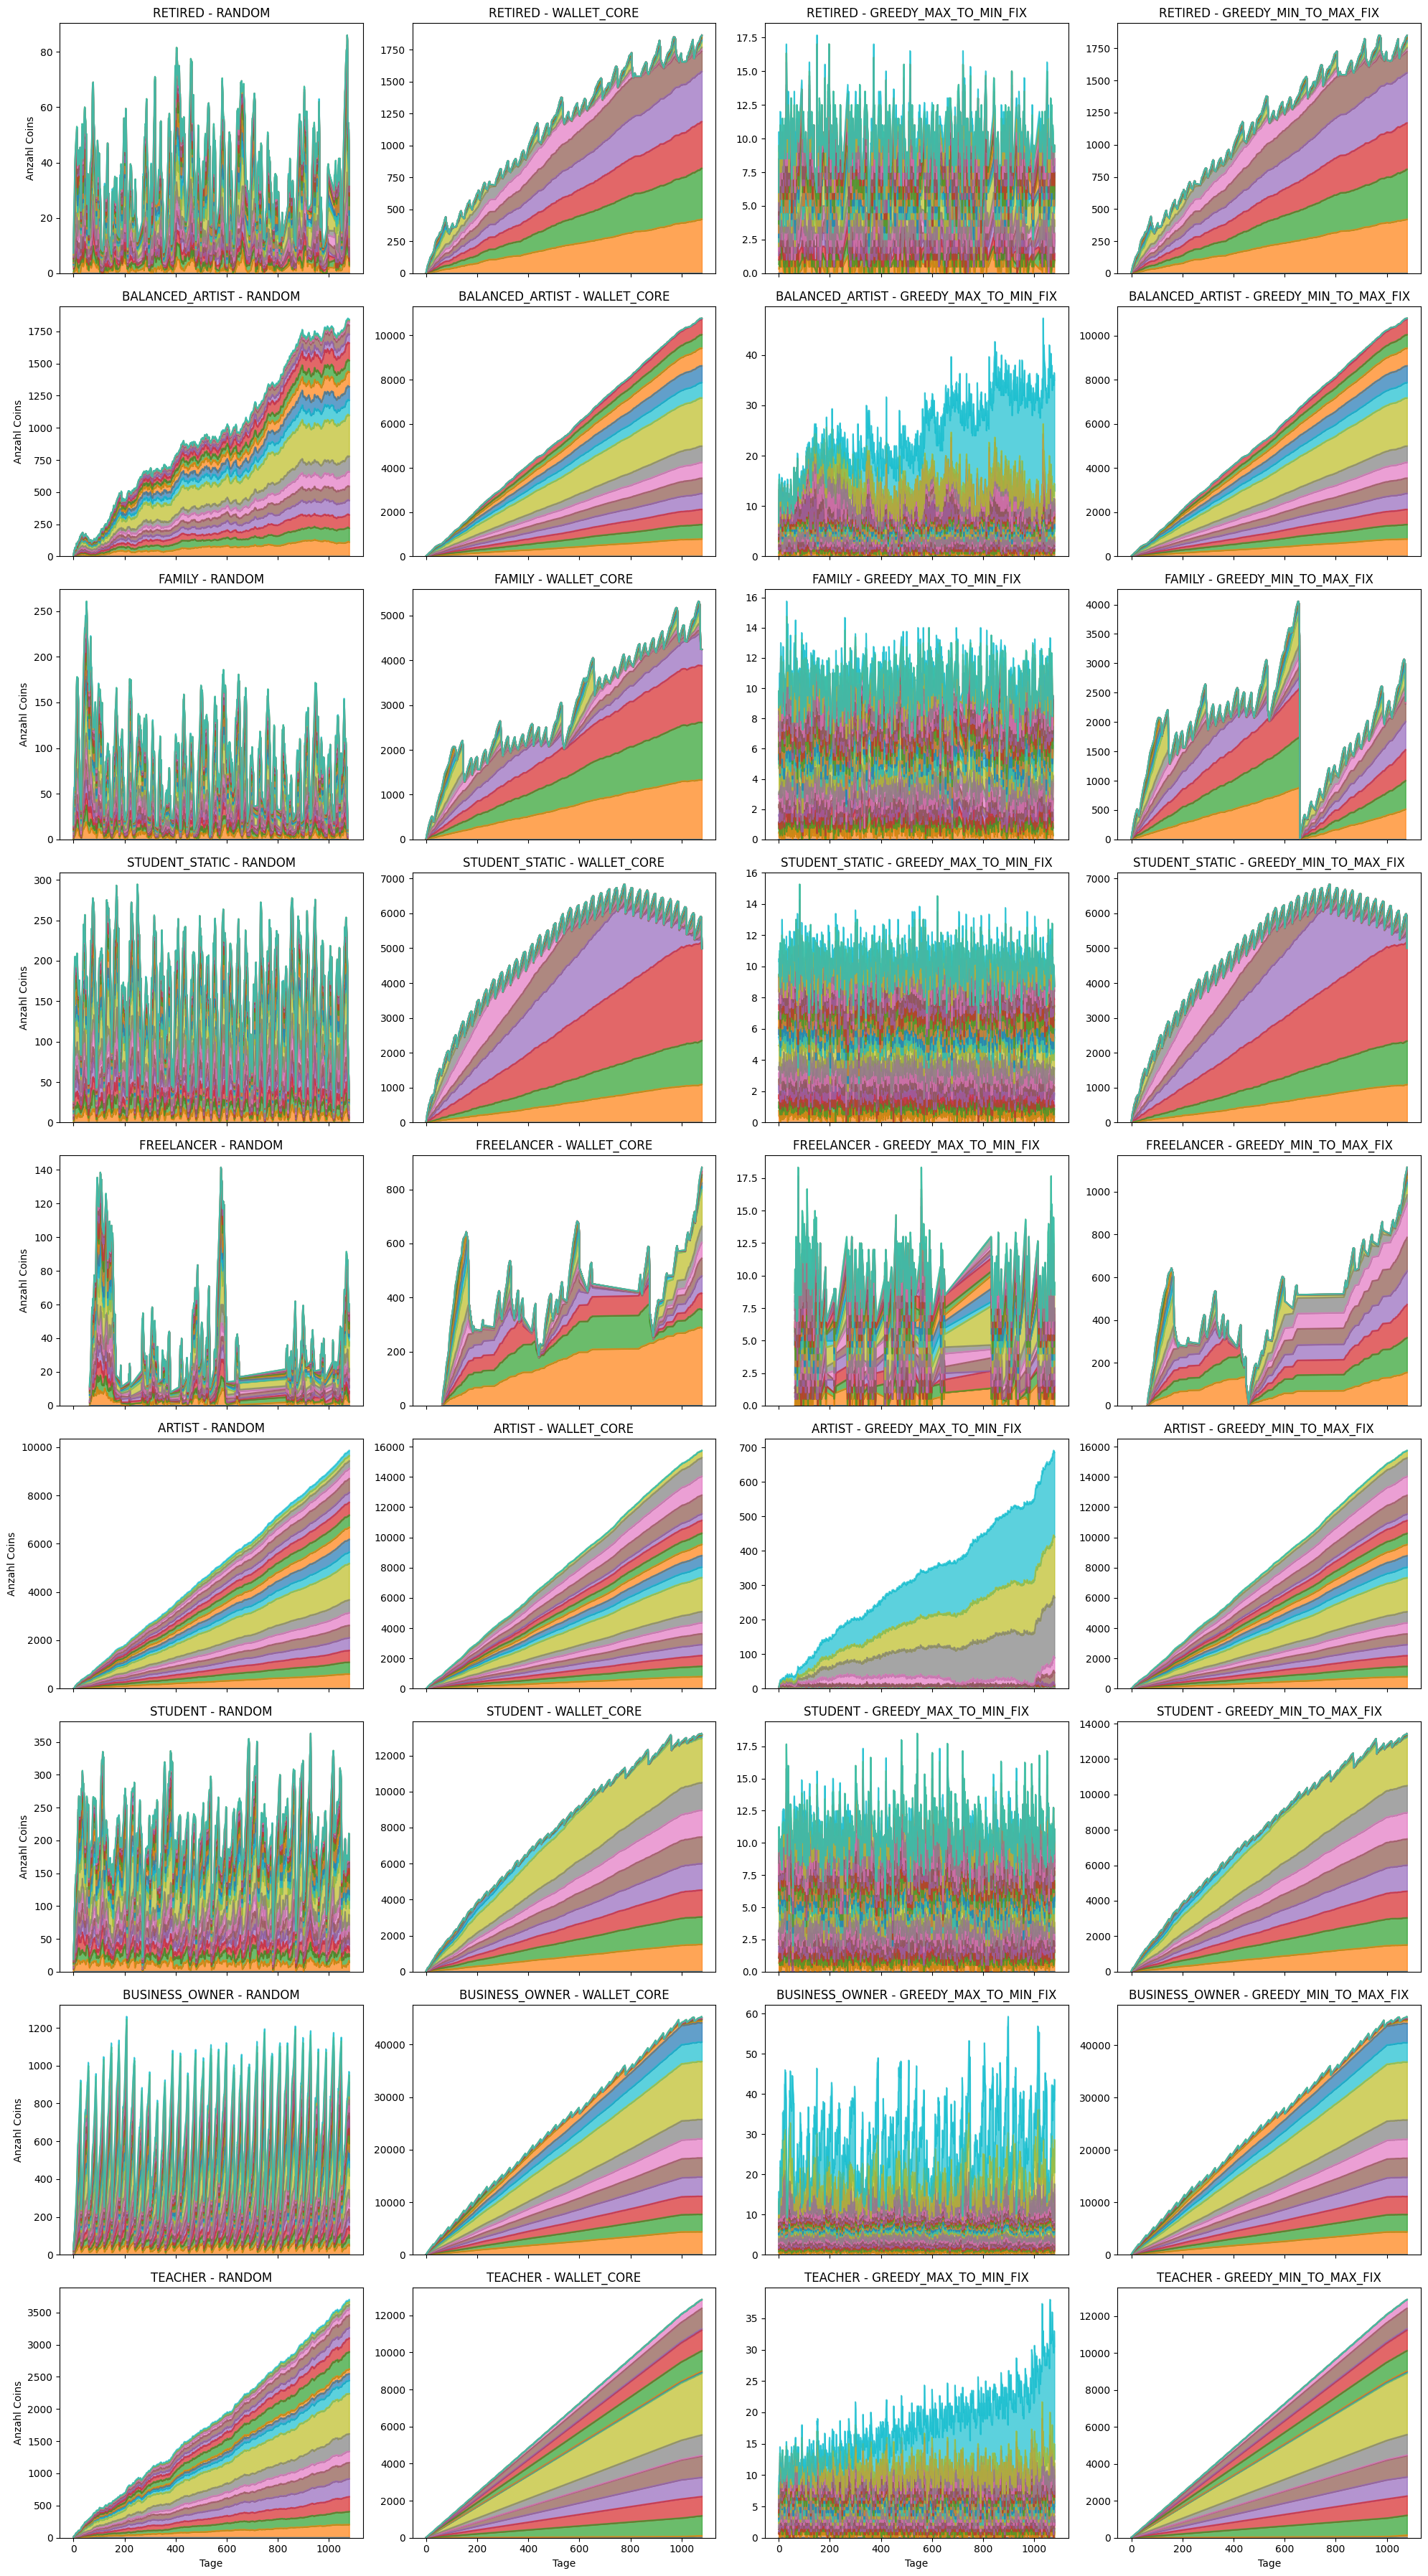

In [22]:
df['Denom'] = df['CoinCounts'].apply(lambda x: list(range(1, len(x)+1)))
df_long = df.explode(['CoinCounts', 'Denom']).rename(columns={'CoinCounts': 'Wert'})

#df_long['Wert'] = pd.to_numeric(df_long['Wert'], errors='coerce')
#df_long['Denom'] = pd.to_numeric(df_long['Denom'], errors='coerce')

# Dann MultiIndex setzen:
df_long = df_long.reset_index().set_index(['Days', 'Denom'])

df_pivot = df_long.reset_index().pivot_table(
    values='Wert', 
    index='Days', 
    columns='Denom'
)

# Alle Kombinationen von Nutzer und Strategie
nutzer = df_long.reset_index()['UserType'].unique()
strategien = df_long.reset_index()['Strategy'].unique()

# Raster erstellen
n_nutzer = len(nutzer)
n_strategien = len(strategien)

fig, axes = plt.subplots(n_nutzer, n_strategien, 
                         figsize=(5*n_strategien, 4*n_nutzer),
                         sharex=True)

# Falls nur 1 Nutzer oder 1 Strategie, axes zu 2D array machen
if n_nutzer == 1:
    axes = axes.reshape(1, -1)
if n_strategien == 1:
    axes = axes.reshape(-1, 1)

# Jeden Subplot füllen
for i, nutzer_name in enumerate(user_types):
    for j, strategie_name in enumerate(strategies):
        # Daten filtern
        mask = (df_long.reset_index()['UserType'] == nutzer_name) & \
               (df_long.reset_index()['Strategy'] == strategie_name)
        df_subset = df_long.reset_index()[mask]
        
        # Pivot und plotten
        df_plot = df_subset.pivot_table(values='Wert', index='Days', columns='Denom')
        df_plot.plot.area(ax=axes[i, j], legend=False, alpha=0.7)
        axes[i, j].set_title(f'{nutzer_name} - {strategie_name}')
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel('')

# Achsenbeschriftungen für die äußeren Plots
for i in range(n_nutzer):
    axes[i, 0].set_ylabel('Anzahl Coins')
for j in range(n_strategien):
    axes[-1, j].set_xlabel('Tage')


plt.tight_layout()
plt.savefig(f"results/all_coin_counts", bbox_inches='tight')
plt.show()


In [ ]:
# Plotting setup
num_users = df['UserType'].nunique()
ncols = n_strats
nrows = n_user_types

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(30, 35), squeeze=False)

axes = axes.ravel()

key = "UsedDiskSpace"

for idx, (user_type, ax) in enumerate(zip(sorted(user_types), axes)):
    # Prepare boxplot data; collect lists from each cell in row corresponding to user type
    user_data = df[(df["UserType"] == user_type)]
    for strategy in strategies:
        #ax.bar(boxplot_data, tick_labels=pivot_df_new.columns, showfliers=False)  # Optionally add `showfliers=False` to hide outliers
        current_data = df[(df["UserType"] == user_type) & (df["Strategy"] == strategy)]

        df_plot = df_subset.pivot_table(values='UsedDiskSpace', index='Days')
        
        current_data.plot(y=key, xlabel="Simulation Time (days)", ylabel="", label=strategy, ax=ax)
        ax.set_title(f"User Type: {user_type}", fontsize=26)
        ax.set_ylabel(key, fontsize=22)
        ax.tick_params(axis='x', rotation=45, labelsize=13)

plt.tight_layout()
plt.savefig(f"results/{key}", bbox_inches='tight')
plt.show()